# 📘 Day 30 — KNN: k-Nearest Neighbors

**Author:** Sahil-K-Y 
**Phase:** 3 — Tree Models & SVM 
**Date:** Day 030 of 214-Day AI/ML Roadmap

---
## 📌 Overview

KNN is a **lazy learning** (instance-based) algorithm — it stores the entire training set and makes predictions at query time by finding the **k closest data points**.

### 🎯 Learning Objectives
- Understand **how KNN works** (no explicit training phase)
- Master **distance metrics**: Euclidean, Manhattan, Minkowski, Cosine
- Learn to choose the **optimal k** value
- Understand the **Curse of Dimensionality**
- Explore KNN for both **classification and regression**

---
## 🧠 1. How KNN Works

### Algorithm Steps:
1. **Store** all training data (no fitting!)
2. For a new query point:
   - Calculate **distance** to ALL training points
   - Find the **k nearest neighbors**
   - **Classification:** Take majority vote of neighbors' labels
   - **Regression:** Take mean (or weighted mean) of neighbors' values

### Key Properties
| Property | Description |
|----------|-------------|
| **Type** | Non-parametric, lazy learner |
| **Training** | O(1) — just stores data |
| **Prediction** | O(n·d) — computes distance to all n points in d dimensions |
| **Memory** | O(n·d) — stores entire dataset |
| **Decision Boundary** | Non-linear, adapts to local data structure |

---
## 🧠 2. Distance Metrics

### 2.1 Euclidean Distance (L2 Norm)
The **straight-line** distance between two points. Most commonly used.

$$d(x, y) = \sqrt{\sum_{i=1}^{n}(x_i - y_i)^2}$$

### 2.2 Manhattan Distance (L1 Norm)
Sum of **absolute differences** along each axis. Better for grid-like paths.

$$d(x, y) = \sum_{i=1}^{n}|x_i - y_i|$$

### 2.3 Minkowski Distance (Generalized)
Generalization of both Euclidean (p=2) and Manhattan (p=1).

$$d(x, y) = \left(\sum_{i=1}^{n}|x_i - y_i|^p\right)^{1/p}$$

### 2.4 Cosine Similarity
Measures the **angle** between two vectors, not magnitude. Great for text.

$$\text{cosine}(x, y) = \frac{x \cdot y}{||x|| \cdot ||y||}$$

### When to Use Which?
| Metric | Best For |
|--------|----------|
| **Euclidean** | Continuous features, equal scales |
| **Manhattan** | High-dimensional data, sparse features |
| **Cosine** | Text data, TF-IDF vectors |
| **Minkowski** | When you want to tune `p` parameter |

---
## 🧠 3. Choosing Optimal k

| k Value | Effect |
|---------|--------|
| **k = 1** | Very **flexible** boundary, high variance, prone to overfitting |
| **Small k** | Complex decision boundary, sensitive to noise |
| **Large k** | Smoother boundary, more bias, may underfit |
| **k = n** | Always predicts majority class (useless) |

### Rules of Thumb:
- Start with **k = sqrt(n)** where n = number of training samples
- Use **odd k** for binary classification to avoid ties
- Use **cross-validation** to find the optimal k
- Typical range to search: k = 1 to 30

---
## 🧠 4. Curse of Dimensionality

As the number of features increases:
- All points become **approximately equidistant** from each other
- The concept of "nearest neighbor" loses meaning
- KNN performance **degrades significantly** in high dimensions

### Solutions:
- **Feature selection** — remove irrelevant features
- **PCA / dimensionality reduction** before applying KNN
- **Feature scaling** — absolutely critical for KNN

### ⚠️ Feature Scaling is MANDATORY for KNN
KNN uses distance — features on larger scales will **dominate** the distance calculation.
- Always use **StandardScaler** or **MinMaxScaler** before KNN
- This is the #1 mistake beginners make with KNN

---
## 💻 Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline
from scipy.spatial.distance import euclidean, cityblock, cosine

import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
sns.set_palette('Set2')
print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## 📊 Dataset: Wine Quality (Red)

The **Wine Quality** dataset contains physicochemical properties of **red wines** from Portugal. The task is to predict wine quality (score 3-8) based on features like acidity, sugar, pH, alcohol content.

**1599 samples, 11 features** — perfect for exploring KNN with continuous features.

**Why this dataset?** KNN excels with medium-sized datasets having continuous features, and wine quality prediction is a fun real-world problem with meaningful feature differences.

In [2]:
# --- Load Wine Quality (Red) from UCI Repository ---
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
df = pd.read_csv(url, sep=';')

print(f'Shape: {df.shape}')
print(f'\nColumns: {list(df.columns)}')
print(f'\nQuality distribution:\n{df["quality"].value_counts().sort_index()}')
print(f'\nFirst 5 rows:')
df.head()

Shape: (1599, 12)

Columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

Quality distribution:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

First 5 rows:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


---
## ✏️ Exercise 1: EDA & Distance Visualization
Explore the dataset and visualize how distances work.

**Tasks:**
1. Plot distribution of each feature
2. Show correlation heatmap
3. Pick 2 features, plot scatter plot colored by quality
4. Manually compute Euclidean and Manhattan distance between 2 sample points

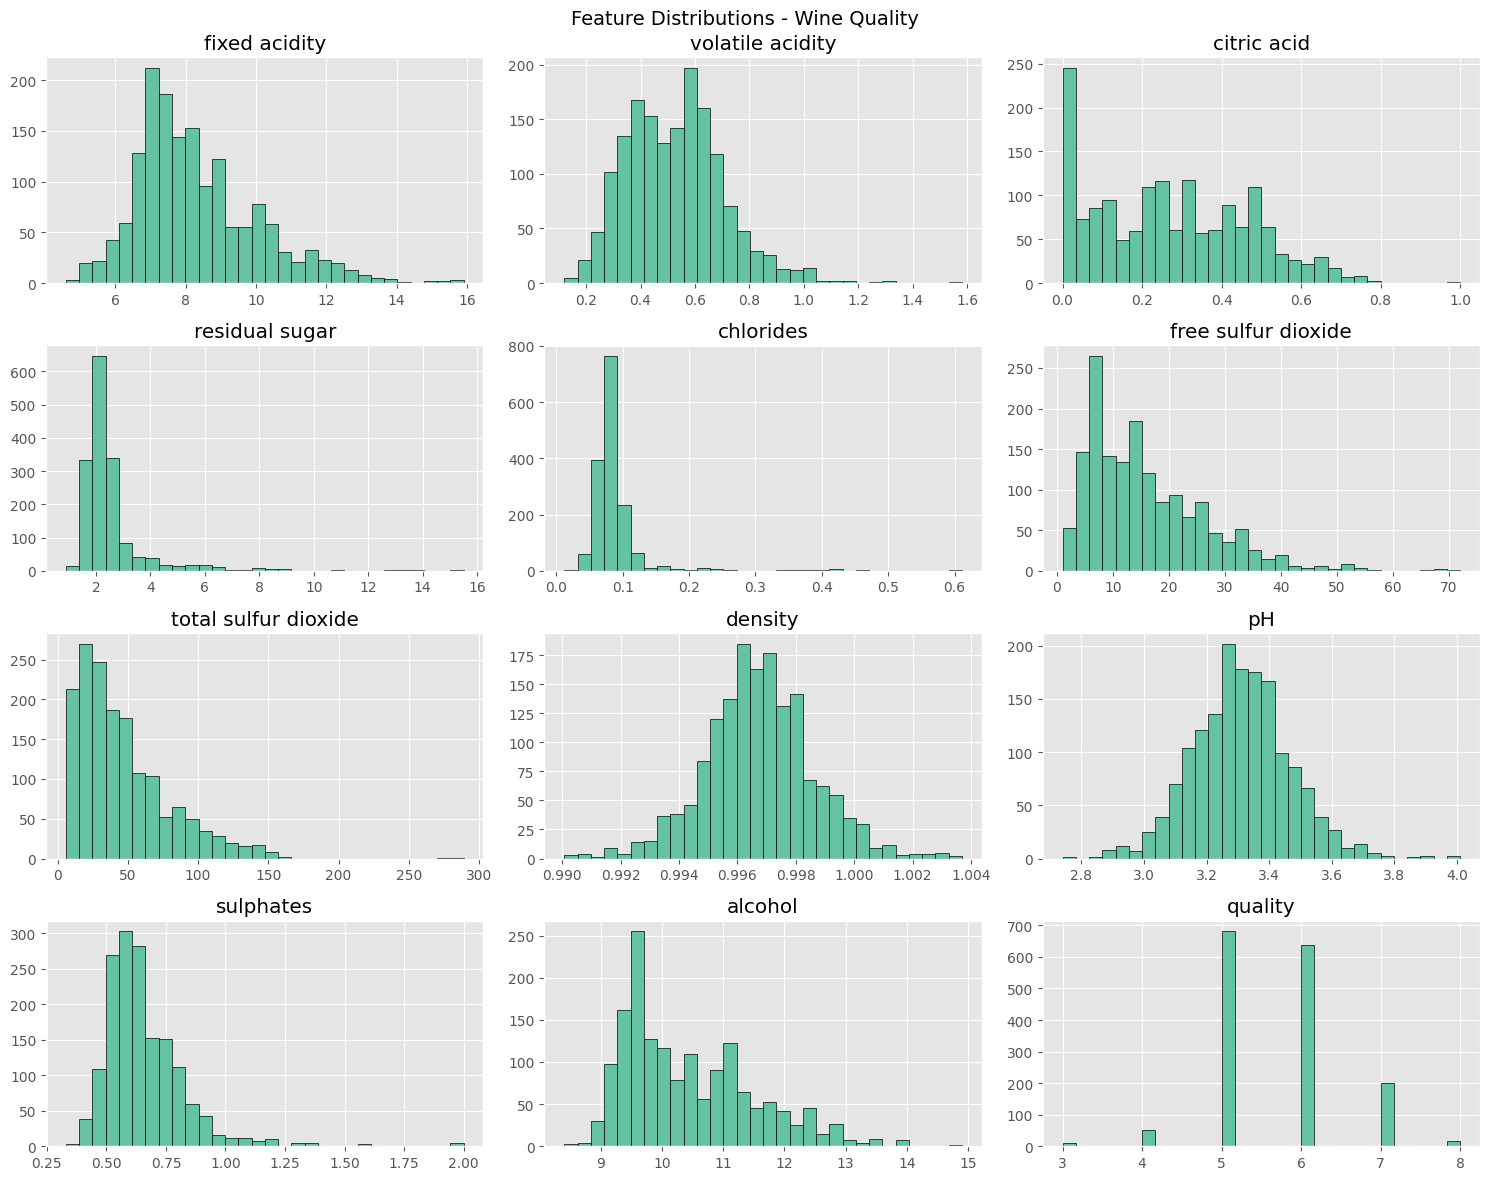

In [18]:
df.hist(figsize=(15, 12), bins=30, edgecolor='black')
plt.suptitle('Feature Distributions - Wine Quality', fontsize=14)
plt.tight_layout()
plt.show()

fixed acidity           0.124052
volatile acidity       -0.390558
citric acid             0.226373
residual sugar          0.013732
chlorides              -0.128907
free sulfur dioxide    -0.050656
total sulfur dioxide   -0.185100
density                -0.174919
pH                     -0.057731
sulphates               0.251397
alcohol                 0.476166
quality                 1.000000
Name: quality, dtype: float64


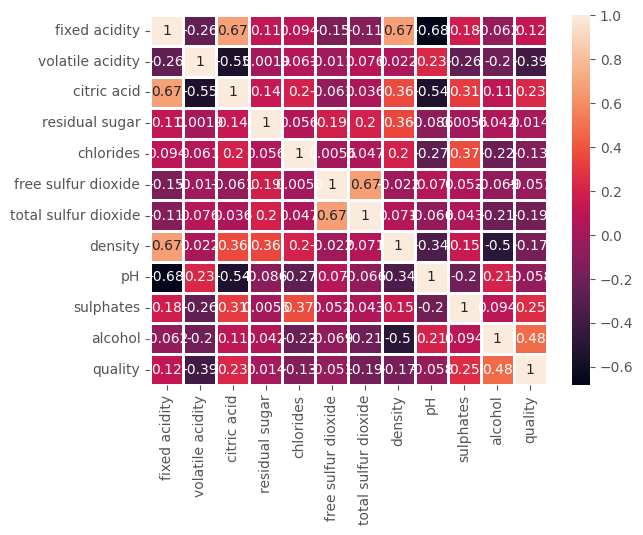

In [24]:
sns.heatmap(df.corr(),annot=True,linewidths=0.95)
print(df.corr()['quality'])

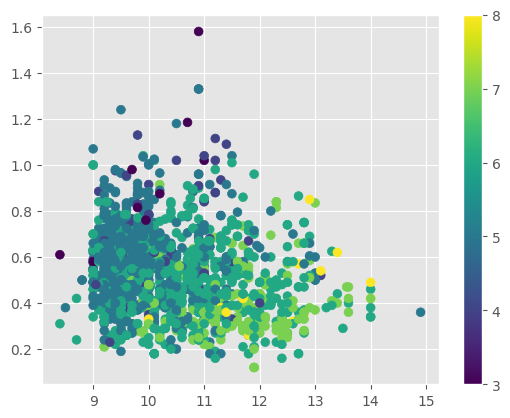

In [28]:
scatter=plt.scatter(df['alcohol'],df['volatile acidity'],c=df['quality'],s=40)
plt.colorbar(scatter)

In [13]:
# YOUR CODE HERE
point1=df.iloc[0][['fixed acidity', 'volatile acidity', 'alcohol']].values
point2 = df.iloc[1][['fixed acidity', 'volatile acidity', 'alcohol']].values

In [16]:
euclidean=np.sqrt(np.sum((point1-point2)**2))
manhattan=np.sum(np.abs(point1-point2))

In [17]:
euclidean

np.float64(0.5936328831862331)

In [29]:
manhattan

np.float64(0.9799999999999999)

In [34]:
cityblock(point1.astype(float),point2.astype(float))

np.float64(0.9799999999999999)

In [36]:
from scipy.spatial.distance import euclidean
euclidean_scipy = euclidean(point1.astype(float), point2.astype(float))
print(euclidean_scipy)  # 0.5936328... aana chahiye, tumhare manual jaisa

0.5936328831862331


---
## ✏️ Exercise 2: KNN Without Scaling vs With Scaling
Demonstrate why **feature scaling is critical** for KNN.

**Tasks:**
1. Split data 80/20
2. Train KNeighborsClassifier (k=5) **without scaling** → record accuracy
3. Train KNeighborsClassifier (k=5) **with StandardScaler** → record accuracy
4. Compare results and explain the difference

In [39]:
# YOUR CODE HERE
X_train,X_test,y_train,y_test=train_test_split(df.drop('quality',axis=1),df['quality'],random_state=42,test_size=0.2,stratify=df['quality'])

In [40]:
knn_unscaled=KNeighborsClassifier(n_neighbors=5)
knn_unscaled.fit(X_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [42]:
y_pred_unscaled=knn_unscaled.predict(X_test)

In [43]:
scaler=StandardScaler()

In [44]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [46]:
knn_scaled=KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [47]:
y_pred_scaled=knn_scaled.predict(X_test_scaled)

In [48]:
acc_scaled=accuracy_score(y_test,y_pred_scaled)
acc_unscaled=accuracy_score(y_test,y_pred_unscaled)

In [49]:
print(f"accuracy of scaled:{acc_scaled:.4f}")
print(f"accuracy of unscaled:{acc_unscaled:.4f}")

accuracy of scaled:0.6094
accuracy of unscaled:0.4844


---
## ✏️ Exercise 3: Finding Optimal k
Use cross-validation to find the best k value.

**Tasks:**
1. Test k values from 1 to 30
2. Use 5-fold CV for each k
3. Plot k vs mean CV accuracy (with std error bars)
4. Print the optimal k

In [73]:
# YOUR CODE HERE
k=list(range(1,30))
score={}
for i in k:
    knn=KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_scaled,y_train)
    score_of_i=accuracy_score(y_test,knn.predict(X_test_scaled))
    score[i]=score_of_i

In [74]:
score

{1: 0.625,
 2: 0.5875,
 3: 0.575,
 4: 0.58125,
 5: 0.609375,
 6: 0.59375,
 7: 0.59375,
 8: 0.590625,
 9: 0.6,
 10: 0.596875,
 11: 0.590625,
 12: 0.584375,
 13: 0.596875,
 14: 0.58125,
 15: 0.575,
 16: 0.565625,
 17: 0.5625,
 18: 0.584375,
 19: 0.565625,
 20: 0.575,
 21: 0.571875,
 22: 0.575,
 23: 0.575,
 24: 0.578125,
 25: 0.5875,
 26: 0.575,
 27: 0.58125,
 28: 0.58125,
 29: 0.578125}

In [78]:
best_k=max(score,key=score.get)

In [79]:
best_k

1

In [80]:
from sklearn.model_selection import cross_val_score

k_range = range(1, 31)
cv_scores = []
cv_std = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5)
    cv_scores.append(scores.mean())
    cv_std.append(scores.std())

best_k = k_range[np.argmax(cv_scores)]
print(f'Best k: {best_k}, CV Accuracy: {max(cv_scores):.4f}')

Best k: 1, CV Accuracy: 0.6005


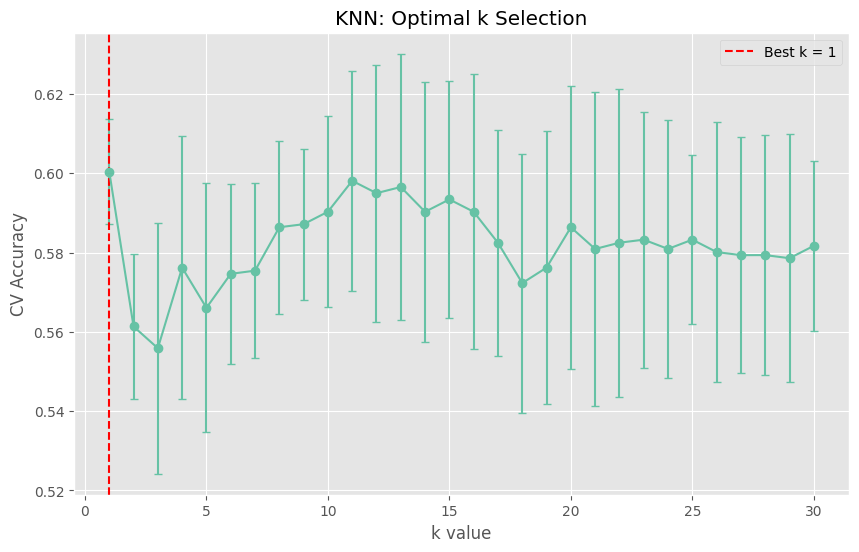

In [81]:
plt.figure(figsize=(10, 6))
plt.errorbar(k_range, cv_scores, yerr=cv_std, marker='o', capsize=3)
plt.axvline(best_k, color='red', linestyle='--', label=f'Best k = {best_k}')
plt.xlabel('k value')
plt.ylabel('CV Accuracy')
plt.title('KNN: Optimal k Selection')
plt.legend()
plt.show()

---
## ✏️ Exercise 4: Distance Metric Comparison
Compare performance with different distance metrics.

**Tasks:**
1. Train KNN with `metric='euclidean'`, `'manhattan'`, and `'minkowski'` (p=3)
2. Use the optimal k from Exercise 3
3. Compare CV accuracies
4. Which metric works best for this dataset?

In [85]:
# YOUR CODE HERE
from sklearn.model_selection import cross_val_score

best_k = 1  # Exercise 3 se jo optimal k mila, wahi use karo

metrics_to_test = {
    'euclidean': {'metric': 'euclidean'},
    'manhattan': {'metric': 'manhattan'},
    'minkowski_p3': {'metric': 'minkowski', 'p': 3}
}

metric_scores = {}

for name, params in metrics_to_test.items():
    knn = KNeighborsClassifier(n_neighbors=best_k, **params)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5)
    metric_scores[name] = scores.mean()
    print(f'{name}: {scores.mean():.4f} (+/- {scores.std():.4f})')


euclidean: 0.6005 (+/- 0.0132)
manhattan: 0.5989 (+/- 0.0317)
minkowski_p3: 0.5950 (+/- 0.0163)


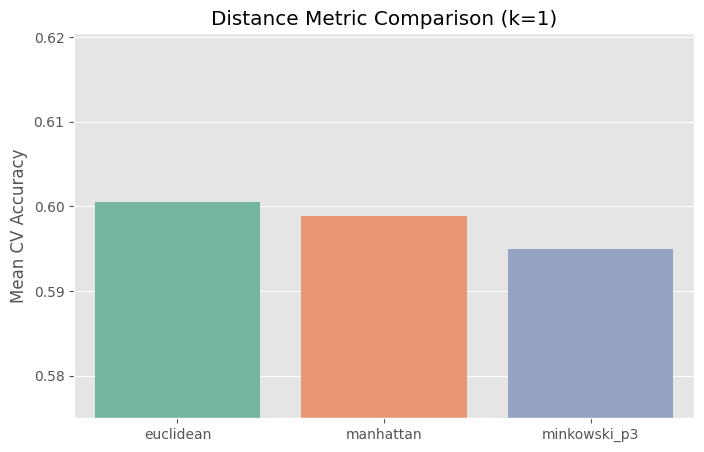

In [86]:
plt.figure(figsize=(8,5))
sns.barplot(x=list(metric_scores.keys()), y=list(metric_scores.values()), palette='Set2')
plt.ylabel('Mean CV Accuracy')
plt.title(f'Distance Metric Comparison (k={best_k})')
plt.ylim(min(metric_scores.values())-0.02, max(metric_scores.values())+0.02)
plt.show()

---
## ✏️ Exercise 5: Weighted KNN
Compare uniform vs distance-weighted KNN.

**Tasks:**
1. Train KNN with `weights='uniform'` vs `weights='distance'`
2. Compare CV accuracies across k = 1 to 20
3. Plot both curves on the same chart
4. Discuss when distance-weighted KNN helps

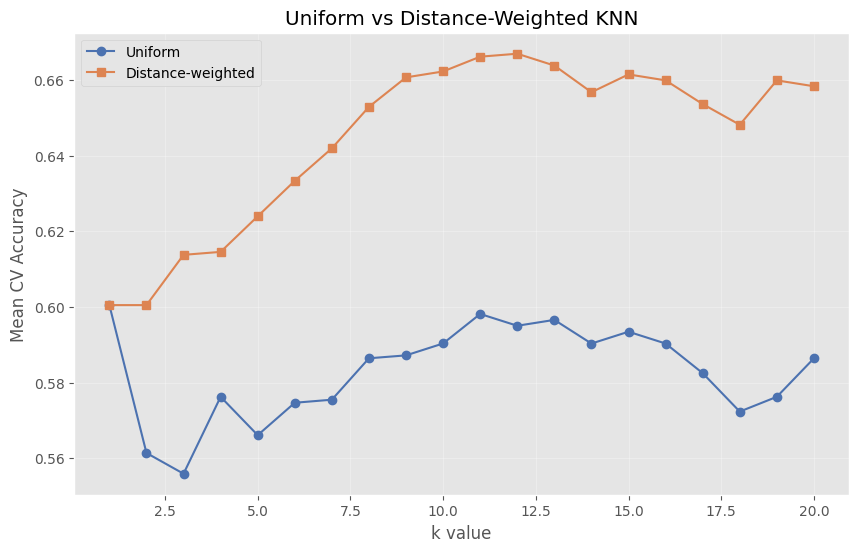

In [87]:
# YOUR CODE HERE
from sklearn.model_selection import cross_val_score

k_range = range(1, 21)
uniform_scores = []
distance_scores = []

for k in k_range:
    knn_u = KNeighborsClassifier(n_neighbors=k, weights='uniform')
    knn_d = KNeighborsClassifier(n_neighbors=k, weights='distance')
    
    uniform_scores.append(cross_val_score(knn_u, X_train_scaled, y_train, cv=5).mean())
    distance_scores.append(cross_val_score(knn_d, X_train_scaled, y_train, cv=5).mean())

plt.figure(figsize=(10,6))
plt.plot(k_range, uniform_scores, marker='o', label='Uniform', color='#4C72B0')
plt.plot(k_range, distance_scores, marker='s', label='Distance-weighted', color='#DD8452')
plt.xlabel('k value')
plt.ylabel('Mean CV Accuracy')
plt.title('Uniform vs Distance-Weighted KNN')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

---
## 📝 Key Takeaways
1. Impact of scaling on KNN: ...
2. Optimal k found: ...
3. Best distance metric: ...
4. Uniform vs Distance weighting: ...